# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?
2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.
3. True or false, and explain: Logistic regression is a linear model.
4. True or false, and explain: Logistic regression cannot be used for classification.
5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?
6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.
7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

1. We use general linear models/latent variable models/activation functions in analysis because unlike linear models, they can accommodate reasonable restrictions on the outcomes (e.g., probabilities ∈ [0,1]). When we pass the linear latent variable into an activation function, we get a prediction.
2. Binary and categorical cross entropy are effective loss functions for fitting logistic regression models because they penalize confident wrong predictions severely. For example, in cce, the further p_ik is from 1 when y_ik = 1, the larger the loss, which we are trying to minimize. Also, cross-entropy is the negative log-likelihood, meaning minimizing it is the same as finding the coefficients that make your data most probable under the model.
3. FALSE. Logistic regression is a non-linear model. It is only linear if A(L) = L, meaning the activation function, when applied to the linear latent variable, evaluates to the linear latent variable.  
4. FALSE. Logistic regression is often used for classification, specifically binary classification. If we "round" the output to 0 or 1, we are doing a classification exercise. We apply a probability threshold to convert the output into a hard classification of either class 0 or class 1, instead of a continuous value between 0 and 1. 
5. The coefficient in a logistic regression does not represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable. Generally, the coefficient means "positive means more likely, negative means less likely." Some people interpret these values in terms of Log-Odds. In non-linear models, changes in x don't impact changes in y in proportion to b. 
6. FALSE. The goal of deep learning is to learn how to do the feature engineering without artisanal hand-crafted feature spaces: It is learning how to represent the data, or how to do representation learning. Feature engineering is important for logistic regression because the model cannot discover structure it isn't given.
7. FALSE. They serve different purposes. You should use OLS for a continuous outcome like price, and logistic regression for a binary or categorical outcome. Logistic regression is preferred when we're looking for probabilities between 0 and 1.

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


In [312]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [313]:
#1
df = pd.read_csv('data.csv', delimiter=';')
cols = ['Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment', 'Curricular units 1st sem (approved)', 'Target']
df = df[cols]

print(f"Missing values per column:\n{df.isnull().sum()}")
# There are no missing values to be handled

df['Dropout'] = (df['Target'] == 'Dropout').astype(int)
print(f"\nDropout counts:\n{df['Dropout'].value_counts()}")

Missing values per column:
Debtor                                 0
Tuition fees up to date                0
Scholarship holder                     0
Age at enrollment                      0
Curricular units 1st sem (approved)    0
Target                                 0
dtype: int64

Dropout counts:
Dropout
0    3003
1    1421
Name: count, dtype: int64


In [314]:
#2
y = df['Dropout']
lr = LogisticRegression(max_iter=1000, random_state=556)
X = df[['Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment', 'Curricular units 1st sem (approved)']]
lr.fit(X, y)
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': lr.coef_[0]})
print(coef_df.to_string(index=False))

# Age at enrollment and debtor predict a higher dropout probability
# Tuition fees and scholarship holder predict a lower dropout probability
# Being up to date on tuition seems to strongly reduce dropout risk

                            Feature  Coefficient
                             Debtor     0.535626
            Tuition fees up to date    -2.409396
                 Scholarship holder    -0.932049
                  Age at enrollment     0.057129
Curricular units 1st sem (approved)    -0.429119


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


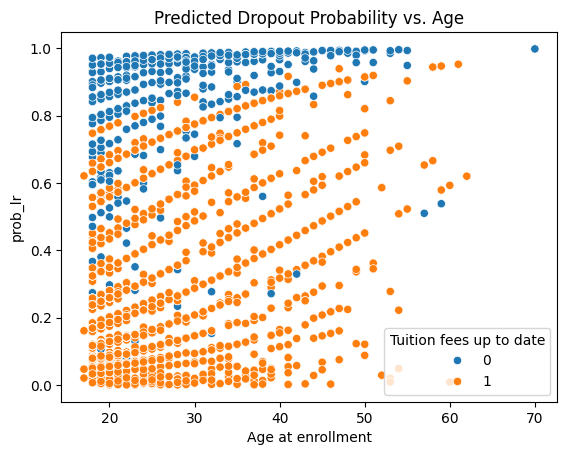

0.6128985930123477


In [315]:
#3
df['prob_lr'] = lr.predict_proba(X)[:, 1]

sns.scatterplot(x = df['Age at enrollment'], y = df['prob_lr'], hue = df['Tuition fees up to date'])
plt.legend(title='Tuition fees up to date')
plt.title('Predicted Dropout Probability vs. Age')
plt.show()

avg_not_uptodate = df.loc[df['Tuition fees up to date'] == 0, 'prob_lr'].mean()
avg_uptodate = df.loc[df['Tuition fees up to date'] == 1, 'prob_lr'].mean()
print(avg_not_uptodate - avg_uptodate)

# For ages 18–30, tuition status seems to reduce dropout probability the most
# Being up to date on tuition reduces predicted dropout probability by ~0.61 percentage points on average

In [316]:
#4
cm = pd.crosstab(y, lr.predict(X))
print(cm)
acc = np.trace(cm)/len(y)
print('Accuracy: ', acc)

col_0       0    1
Dropout           
0        2754  249
1         484  937
Accuracy:  0.8343128390596745


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


LR prob range: [3.298184355719125e-05, 0.9984495494156401]
LM prob range: [-0.9341237891617614, 1.493686936679206]
LR Accuracy: 0.8343128390596745
LM Accuracy (threshold 0.5): 0.8327305605786618


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


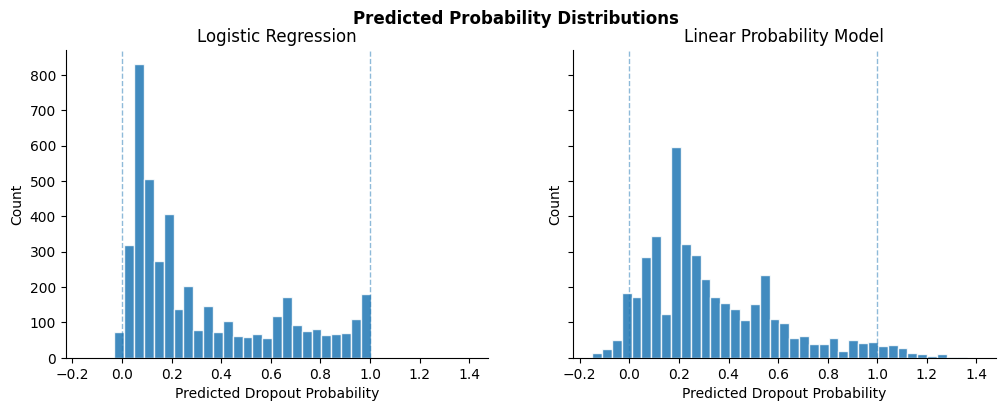

In [317]:
#5
lm = LinearRegression()
lm.fit(X, y)
df['prob_lm'] = lm.predict(X)

y_pred_lm = (df['prob_lm'] >= 0.5).astype(int)
acc_lm = accuracy_score(y, y_pred_lm)
 
print(f"LR prob range: [{df['prob_lr'].min()}, {df['prob_lr'].max()}]")
print(f"LM prob range: [{df['prob_lm'].min()}, {df['prob_lm'].max()}]")
print(f"LR Accuracy: {acc}")
print(f"LM Accuracy (threshold 0.5): {acc_lm}")
 
bins = np.linspace(-0.15, 1.4, 40)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, col, title in [                                        
        (axes[0], 'prob_lr', 'Logistic Regression'),
        (axes[1], 'prob_lm', 'Linear Probability Model')]:
    ax.hist(df[col], bins=bins, edgecolor='white', alpha=0.85) 
    ax.axvline(0, lw=1, ls='--', alpha=0.5)
    ax.axvline(1, lw=1, ls='--', alpha=0.5)
    ax.set_xlabel('Predicted Dropout Probability')
    ax.set_ylabel('Count')
    ax.set_title(title)
    ax.spines[['top', 'right']].set_visible(False)
fig.suptitle('Predicted Probability Distributions', fontweight='bold')
plt.show()

# The logistic regression predicts mainly low dropout probabilities like 0.1
# The linear model has a much wider distribution, predicting more central probabilities
# The logistic regression predicts probabilities between 0 and 0.998 
# The linear model predicts probabilities below 0 and above 1, which is impossible

#6 

Based on the above work, those who do not pay their tuition on time and those in debt are most at risk of dropping out.

If we established payment plans to ensure people are paying their tuition and helped people in debt find jobs, we could help those at-risk stay enrolled by aiding their finances. 

Classes predicted by hard classifier: ['Dropout' 'Graduate']

Confusion matrix (rows=true, cols=predicted) [Dropout, Enrolled, Graduate]:
[[1054    0  367]
 [ 280    0  514]
 [ 146    0 2063]]
Accuracy: 0.7045660036166366


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/L

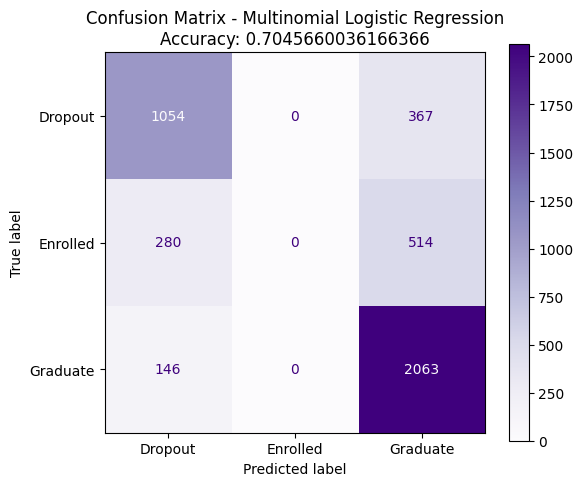


First 5 rows of predicted probabilities:
    Dropout  Enrolled  Graduate
0  0.680547  0.210464  0.108989
1  0.695414  0.146043  0.158543
2  0.952988  0.041199  0.005813
3  0.117808  0.176983  0.705209
4  0.184227  0.212669  0.603104

Mean predicted probability per class:
Dropout     0.321223
Enrolled    0.179474
Graduate    0.499303
dtype: float64


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [318]:
#7 
X2 = df[['Debtor', 'Tuition fees up to date',  'Curricular units 1st sem (approved)']]
y2 = df['Target']

mlr = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')
mlr.fit(X2, y2)
 
y_pred_mlr = mlr.predict(X2)
print(f"Classes predicted by hard classifier: {np.unique(y_pred_mlr)}")
 
cm_mlr = confusion_matrix(y2, y_pred_mlr, labels=['Dropout', 'Enrolled', 'Graduate'])
acc_mlr = accuracy_score(y2, y_pred_mlr)
print(f"\nConfusion matrix (rows=true, cols=predicted) [Dropout, Enrolled, Graduate]:\n{cm_mlr}")
print(f"Accuracy: {acc_mlr}")
 
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm_mlr,
                       display_labels=['Dropout', 'Enrolled', 'Graduate']).plot(ax=ax, cmap='Purples')
ax.set_title(f'Confusion Matrix - Multinomial Logistic Regression\nAccuracy: {acc_mlr}')
plt.tight_layout()
plt.savefig('fig4_confusion_multi.png', dpi=150, bbox_inches='tight')
plt.show()
 
proba_multi = mlr.predict_proba(X2)
proba_df = pd.DataFrame(proba_multi, columns=mlr.classes_)
print(f"\nFirst 5 rows of predicted probabilities:\n{proba_df.head().to_string()}")
print(f"\nMean predicted probability per class:\n{proba_df.mean()}")

# No the hard prediction does not predict every class; it does not predict 'enrolled'
# However, the predicted probabilities predict every class
# The mean probabilities show the model "knows" 'enrolled' exists, it just never wins the argmax in prediction

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics 
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class? 

In [319]:
#1
cir = pd.read_csv('cirrhosis.csv')
COLS = ['Bilirubin', 'Edema', 'Drug', 'Stage', 'Status']
cir = cir[COLS]

print(f"Missing values per column:\n{cir.isnull().sum()}")
cir = cir.dropna(subset=['Drug', 'Stage'])

# I dropped the rows with missing Drug and Stage values

Missing values per column:
Bilirubin      0
Edema          0
Drug         106
Stage          6
Status         0
dtype: int64


In [320]:
#2
cir['Edema'] = cir['Edema'].map({'N': 0, 'S': 1, 'Y': 2})
cir['Drug']  = (cir['Drug'] == 'D-penicillamine').astype(int)
cir['Status'] = (cir['Status'] != 'D').astype(int)
X_cir = cir[['Drug', 'Edema', 'Bilirubin']]

y_cir = cir['Status']
lr_cir = LogisticRegression(max_iter=1000, random_state=556)
lr_cir.fit(X_cir, y_cir)
coef_df_cir = pd.DataFrame({'Feature': X_cir.columns, 'Coefficient': lr_cir.coef_[0]})
print(coef_df_cir.to_string(index=False))

# The drug does not improve survival probability because its coefficient is negative
# Higher bilirubin predicts a lower survival rate due to its negative coefficient
# Higher edema severity predicts a lower survival rate due to its negative coefficient

  Feature  Coefficient
     Drug    -0.223469
    Edema    -0.915295
Bilirubin    -0.348584


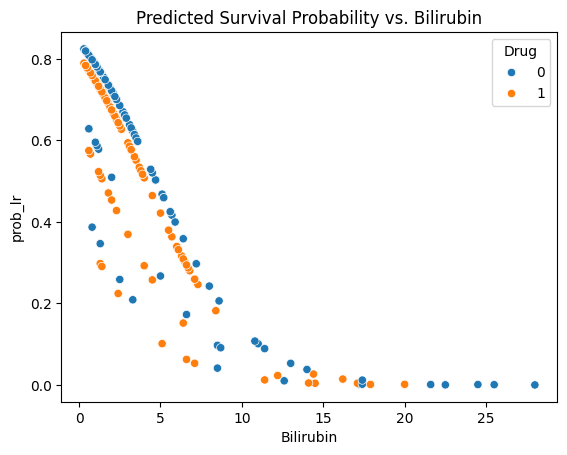

Avg survival prob (Placebo): 0.6089283811813531
Avg survival prob (D-penicillamine): 0.5900207099407194
Avg difference (drug - placebo): -0.01890767124063364


In [321]:
#3
cir['prob_lr'] = lr_cir.predict_proba(X_cir)[:, 1]

sns.scatterplot(x = cir['Bilirubin'], y = cir['prob_lr'], hue = cir['Drug'])
plt.legend(title='Drug')
plt.title('Predicted Survival Probability vs. Bilirubin')
plt.show()

avg_placebo = cir.loc[cir['Drug'] == 0, 'prob_lr'].mean()
avg_drug = cir.loc[cir['Drug'] == 1, 'prob_lr'].mean()
print(f"Avg survival prob (Placebo): {avg_placebo}")
print(f"Avg survival prob (D-penicillamine): {avg_drug}")
print(f"Avg difference (drug - placebo): {avg_drug - avg_placebo}")

# Based on the plot, the drug does not increase survival probability at any range of bilirubin
# On average, patients who take the drug see a −0.0189 change in predicted survival probability compared to placebo

In [322]:
#4
cm_cir = pd.crosstab(y_cir, lr_cir.predict(X_cir))
print(cm_cir)
acc_cir = np.trace(cm_cir)/len(y_cir)
print('Accuracy: ', acc_cir)

col_0    0    1
Status         
0       60   65
1       14  173
Accuracy:  0.7467948717948718


LR prob range: [0.0001202486534336686, 0.8242247641139234]
LM prob range: [-0.4677790863907135, 0.775735758429751]
LR Accuracy: 0.7467948717948718
LM Accuracy (threshold 0.5): 0.7275641025641025


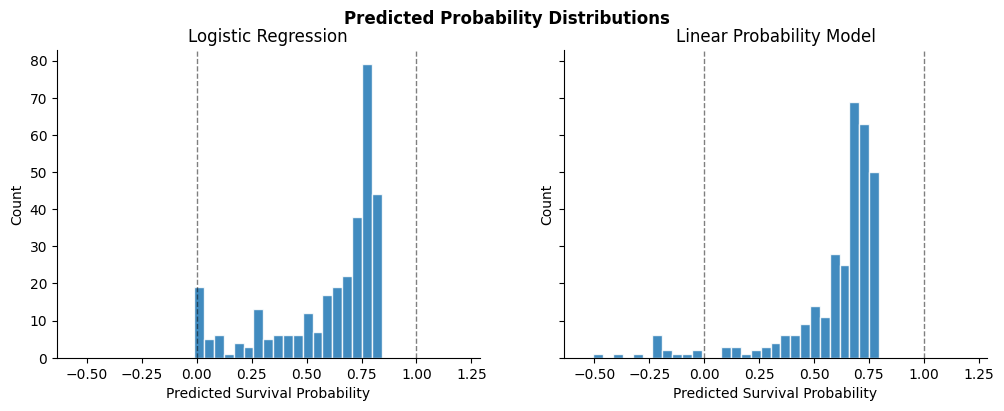

In [323]:
#5
lm_cir = LinearRegression()
lm_cir.fit(X_cir, y_cir)
cir['prob_lm'] = lm_cir.predict(X_cir)

y_pred_lm_cir = (cir['prob_lm'] >= 0.5).astype(int)
acc_lm_cir = accuracy_score(y_cir, y_pred_lm_cir)
 
print(f"LR prob range: [{cir['prob_lr'].min()}, {cir['prob_lr'].max()}]")
print(f"LM prob range: [{cir['prob_lm'].min()}, {cir['prob_lm'].max()}]")
print(f"LR Accuracy: {acc_cir}")
print(f"LM Accuracy (threshold 0.5): {acc_lm_cir}")
 
bins = np.linspace(-0.55, 1.2, 40)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, col, title in [
        (axes[0], 'prob_lr', 'Logistic Regression'),
        (axes[1], 'prob_lm', 'Linear Probability Model')]:
    ax.hist(cir[col], bins=bins, edgecolor='white', alpha=0.85)
    ax.axvline(0, color='black', lw=1, ls='--', alpha=0.5)
    ax.axvline(1, color='black', lw=1, ls='--', alpha=0.5)
    ax.set_xlabel('Predicted Survival Probability')
    ax.set_ylabel('Count')
    ax.set_title(title)
    ax.spines[['top', 'right']].set_visible(False)
fig.suptitle('Predicted Probability Distributions', fontweight='bold')
plt.show()

# The logistic regression predicts mainly survival probabilities around 0.75
# The linear model predicts slightly lower survivor probabilities, with the maximum being ~0.776
# The two shapes are similar
# The logistic regression predicts probabilities between 0.0001 and 0.824 
# The linear model predicts probabilities below 0, which is impossible


In [324]:
#6
X_s = cir[['Edema', 'Bilirubin']]
y_s = cir['Stage'].astype(int).astype(str)
 
stage_lr = LogisticRegression(max_iter=1000, random_state=42)
stage_lr.fit(X_s, y_s)
 
y_pred_s = stage_lr.predict(X_s)
 
cm_stage = pd.crosstab(y_s, stage_lr.predict(X_s))
print(cm_stage)
acc_stage = np.trace(cm_stage)/len(y_s)
print('Accuracy: ', acc_stage)
 
prob_s  = stage_lr.predict_proba(X_s)
prob_s_df = pd.DataFrame(prob_s, columns=stage_lr.classes_)
prob_s_df.head()

# The hard classification only predicts stages 3 & 4
# The predicted probabilities predict every class, but the probabilities for stages 1 and 2 are much lower than those of 3 & 4, so they never get selected by the hard classifier

col_0    3   4
Stage         
1       16   0
2       61   6
3      102  18
4       74  35
Accuracy:  0.07051282051282051


,1,2,3,4
0,0.000004,0.026212,0.163753,0.810031
1,0.073533,0.252875,0.400994,0.272598
2,0.026874,0.172054,0.337700,0.463372
3,0.021408,0.167391,0.338390,0.472811
4,0.020987,0.227850,0.428140,0.323023


**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio? 

1. The derivative of the prediction with respect to the k-th feature is just b_k. For a 1-unit increase in x_k, the prediction changes by b_k.
2. Using the hint and chain rule, the derivative of $\hat{p_i}$ with respect to the kth feature is $ b_k \hat{p}(1 - \hat{p})$. As x changes, $\hat{p}$ changes, making the derivative change. When b * x is very negative, p approaches 0, so the derivative is ~ 0. When b * x is very large, p approaches 1, so the derivative is ~ 0. When b * x = 0, p = 0.5 and the derivative is its largest. This is different from part 1 because in part 1, the derivative is constant, but in part 2 it changes depending on the $\hat{p}$ which is influenced by x_k. The function $\hat{p}(1−\hat{p})$ is a downward parabola, maximized at exactly $\hat{p}$ = 0.5 with a value of 0.25. It stays reasonably close to 0.25 when $\hat{p}$ is near 0.5. So near $\hat{p}$ = 0.5, the derivative of $\hat{p_i}$ wrt x_k ~= 0.25 b_k, so 4 * the derivative of $\hat{p_i}$ wrt x_k ~= b_k
3. A one unit change in $x_k$ affects the log odds ratio by increasing it by b_k. 